In [1]:
import copy
import datetime as dt

import astropy.units as u
import dill as pk
import numpy as np
from pathlib import Path

import latcom.utils.map_utils as mu
from astropy.time import Time
from sotodlib import core
from latcom.utils.optical_loading import pwv_interp
from latcom.utils.parsing import parse_dict

#import socolors

%load_ext autoreload
%autoreload 2

In [2]:
import dill as pk
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pwv = pwv_interp()

with open("../../nets/nets_07162026.pk", "rb") as f:
    net_dict = pk.load(f)
c_base = "C0"
c_goal = "C3"

temp_conv_090 = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="baseline")
temp_conv_150 = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="baseline")
temp_conv_220 = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="baseline")
temp_conv_280 = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="baseline")

In [3]:
df = parse_dict(net_dict)

In [4]:
t_cut_low_nominal = Time("2025-10-01T00:00:00", format="isot", scale="utc")
t_cut_high_nominal = Time("2025-11-16T00:00:00", format="isot", scale="utc")

t_cut_low = Time("2026-06-01T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-08-01T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df.labels)
nominal_means = np.zeros(len(set_labels))
aso_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
        & (df.t_obs < t_cut_high_nominal.unix)
        & (t_cut_low_nominal.unix < df.t_obs)
        & (df.labels == label)
    ).nets
    nominal_means[i] = np.sum(1 / data) / np.sum(1 / data**2)

    data = df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df.labels == label)
    ).nets
    aso_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
means_df = pd.DataFrame({"labels": set_labels, "nominal_nets": nominal_means, "aso_nets":aso_means})
nominal_ufms = np.array([label for i, label in enumerate(means_df.labels.to_numpy()) if not np.isnan(means_df.nominal_nets[i])])

aso = means_df[means_df["labels"].isin(nominal_ufms)]["aso_nets"]
nominal = means_df[means_df["labels"].isin(nominal_ufms)]["nominal_nets"]

/tmp/ipykernel_1027658/2360152551.py:17: RuntimeWarning: invalid value encountered in scalar divide
  nominal_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
/tmp/ipykernel_1027658/2360152551.py:17: RuntimeWarning: invalid value encountered in scalar divide
  nominal_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
/tmp/ipykernel_1027658/2360152551.py:17: RuntimeWarning: invalid value encountered in scalar divide
  nominal_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
/tmp/ipykernel_1027658/2360152551.py:17: RuntimeWarning: invalid value encountered in scalar divide
  nominal_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
/tmp/ipykernel_1027658/2360152551.py:17: RuntimeWarning: invalid value encountered in scalar divide
  nominal_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
/tmp/ipykernel_1027658/2360152551.py:17: RuntimeWarning: invalid value encountered in scalar divide
  nominal_means[i] = np.sum(1 / data) / np.sum(1 / data**2)
/tmp/ipykernel_1027658/2360152551.py:17:

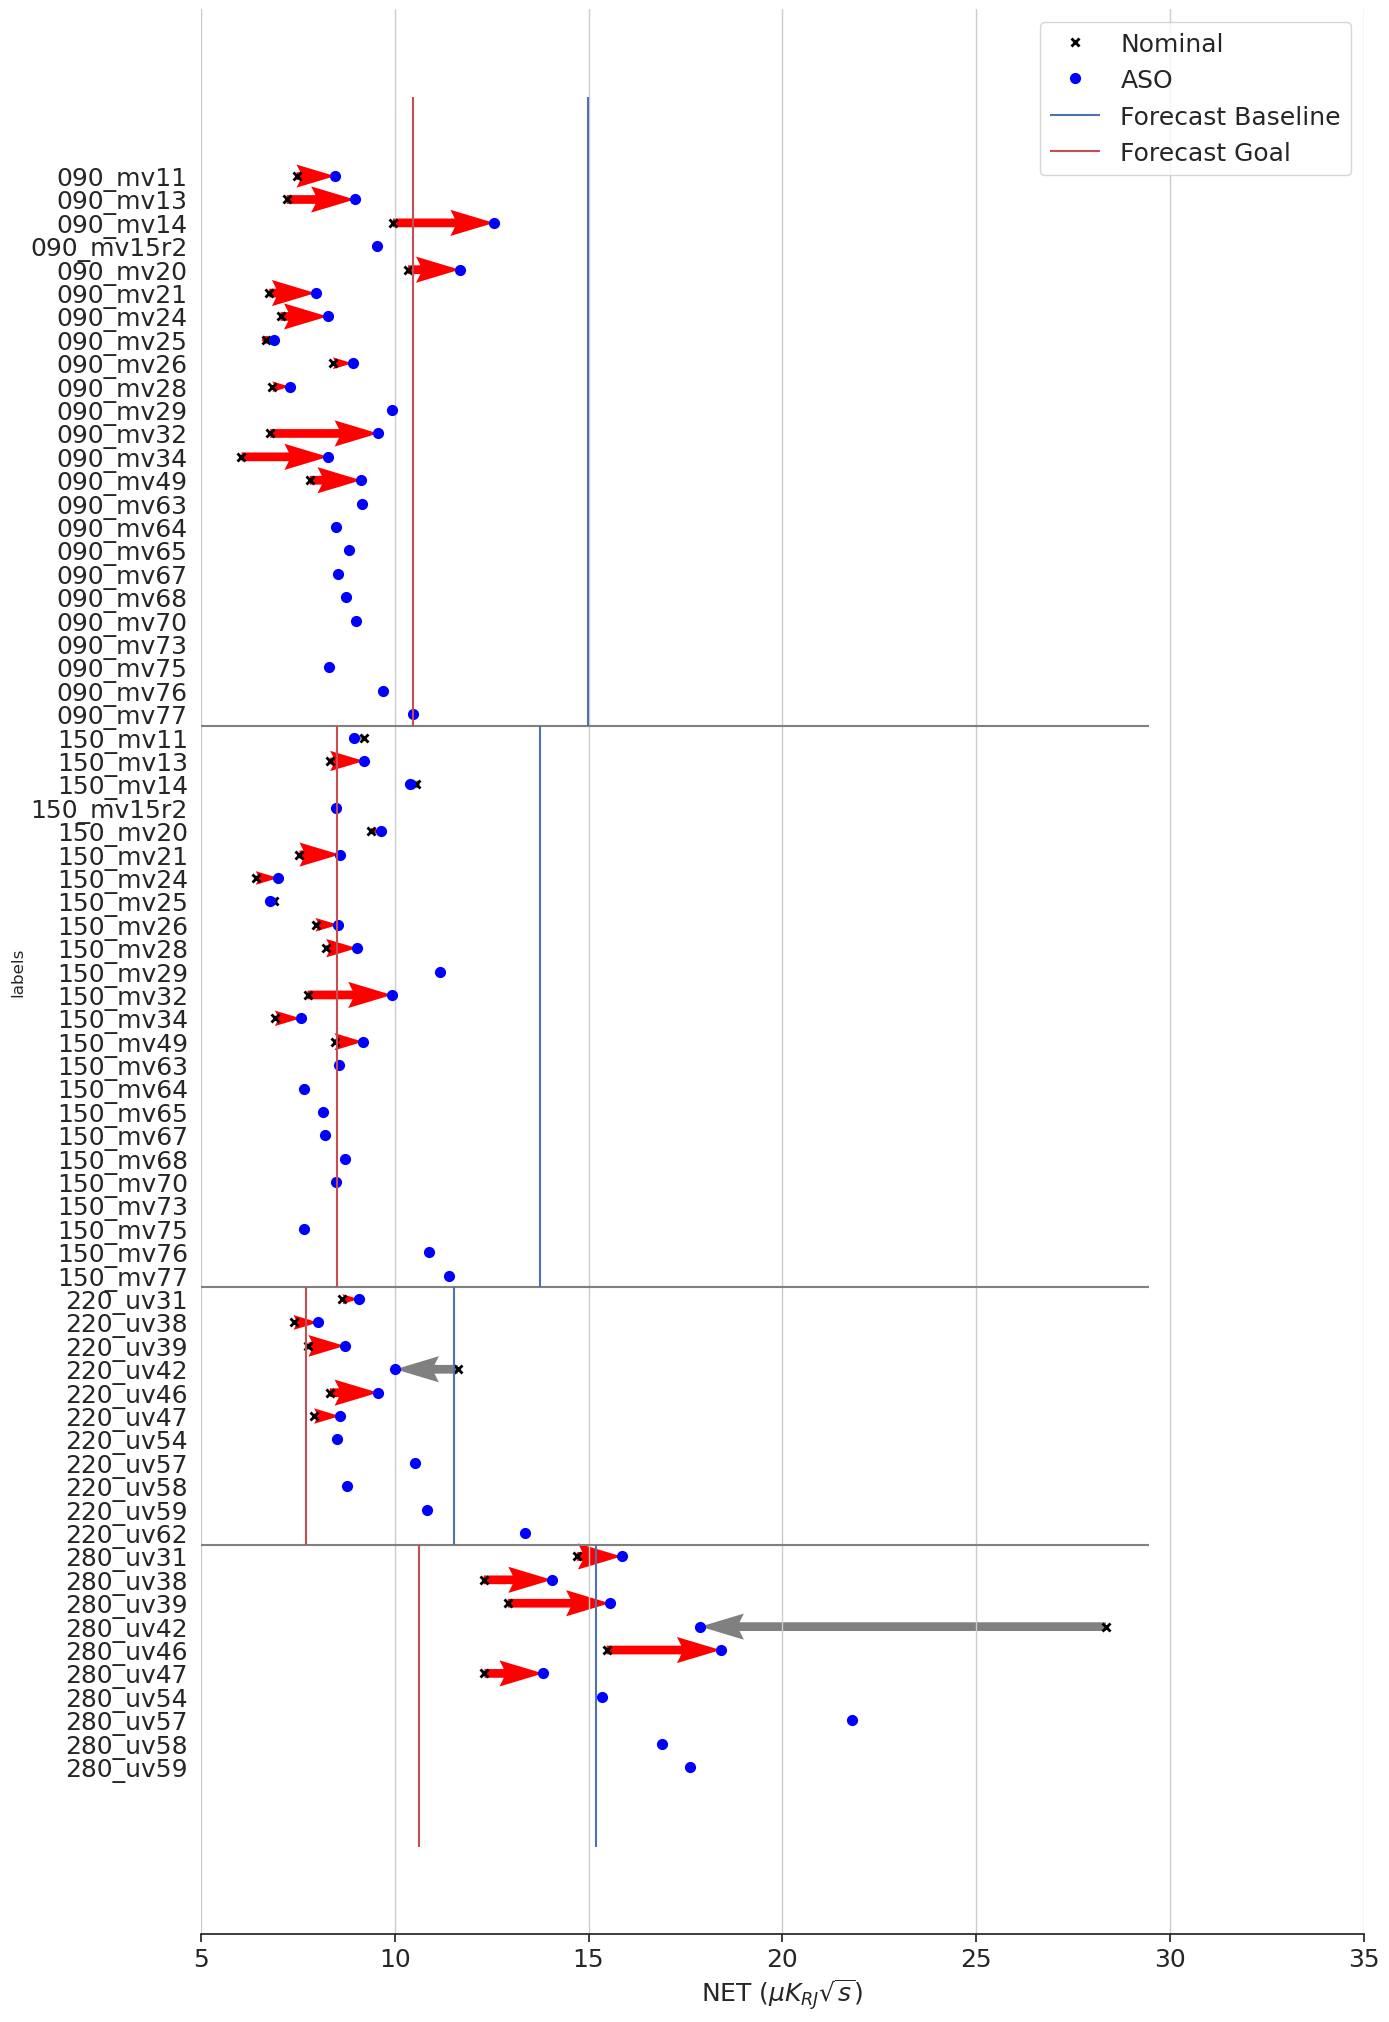

In [12]:
#plt.style.use("apj-fullwidth")
#fontsize = 18
#f, ax = plt.subplots(figsize=(7, 15))
sns.set_theme(style="ticks")
fontsize = 18

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(15, 25))

# Add in points to show each observation
sns.pointplot(data=means_df, x="nominal_nets", y="labels", linestyle="none", marker="x", color="black", zorder=2, label="Nominal", markersize=6)
plot = sns.pointplot(data=means_df, x="aso_nets", y="labels", linestyle="none", marker="o", color="blue", zorder=2, label="ASO", markersize=6)

plot.quiver(
    nominal,  # X arrow start
    means_df[means_df["labels"].isin(nominal_ufms)].index,                   # Y arrow start
    aso-nominal,    # delta X (0 here since we want vertical lines)
    np.zeros_like(aso),                 # delta Y
    scale_units='xy',
    scale=1,
    color=np.where(aso<nominal, 'grey', 'red'),
    zorder=-1,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = len([label for label in set(df.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len([label for label in set(df.labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df.labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df.labels.to_numpy()) if "280" in label])

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5")


# 090 Goals
temp_conv = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_1", kind="baseline")

plt.vlines(5.37 * np.sqrt(12) / temp_conv_090.value, ymin=ymin, ymax=pos_090, label="Forecast Baseline", color=c_base,)
plt.vlines(3.75 * np.sqrt(12) / temp_conv_090.value, ymin=ymin, ymax=pos_090, label="Forecast Goal", color=c_goal,)


# 150 Goals
temp_conv = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="MF", ch="MF_2", kind="baseline")

plt.vlines(6.74 * np.sqrt(12) / temp_conv_150.value, ymin=pos_090, ymax=pos_150, color=c_base)
plt.vlines(4.18 * np.sqrt(12) / temp_conv_150.value, ymin=pos_090, ymax=pos_150, color=c_goal)

# 220 Goals
temp_conv = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_1", kind="baseline")

plt.vlines(15.00 * np.sqrt(6) / temp_conv_220.value, ymin=pos_150, ymax=pos_220, color=c_base)
plt.vlines(10.04 * np.sqrt(6) / temp_conv_220.value, ymin=pos_150, ymax=pos_220, color=c_goal)

# 280 Goals
temp_conv = mu.temp_conv(T_B=2.725 * u.Kelvin, flavor="UHF", ch="UHF_2", kind="baseline")

plt.vlines(35.88 * np.sqrt(6) / temp_conv_280.value, ymin=pos_220, ymax=ymax, color=c_base)
plt.vlines(25.11 * np.sqrt(6) / temp_conv_280.value, ymin=pos_220, ymax=ymax, color=c_goal)

plt.xlim(5, 35)

# Tweak the visual presentation
ax.xaxis.grid(True)
# ax.set(xlabel="NET ($\mu K_{RJ} \sqrt{s}$)", ylabel="", yticklabels=[])
ax.set_xlabel(r"NET ($\mu K_{RJ} \sqrt{s}$)", fontsize=fontsize)
#ax.set_ylabel("", fontsize=fontsize)
#ax.set_yticklabels([])
ax.tick_params(left=False, labelsize=fontsize)
sns.despine(trim=True, left=True)

plt.legend(fontsize=fontsize)
output_dir = Path(f"../../plts/nets/")
output_dir.mkdir(parents=True, exist_ok=True)
f.savefig(output_dir / "nominal_nets_asopreproc.pdf", dpi=600, bbox_inches="tight")
f.savefig(output_dir / "nominal_nets_asopreproc.png", dpi=600, bbox_inches="tight")

# Yields

In [30]:
t_cut_low = Time("2026-06-01T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-08-01T00:00:00", format="isot", scale="utc")

t_cut_low_nominal = Time("2025-10-01T00:00:00", format="isot", scale="utc")
t_cut_high_nominal = Time("2025-11-16T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df.labels)
nominal_means = np.zeros(len(set_labels))
aso_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
        & (df.t_obs < t_cut_high_nominal.unix)
        & (t_cut_low_nominal.unix < df.t_obs)
        & (df.labels == label)
    ).yields
    nominal_means[i] = np.mean(data)

    data = df.where(
        (df.pwv / np.sin(np.deg2rad(df.el)) < 3)
        & (df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df.t_obs)
        & (df.labels == label)
    ).yields
    aso_means[i] = np.mean(data)
means_df = pd.DataFrame({"labels": set_labels, "nominal_yields": nominal_means, "aso_yields":aso_means})
nominal_ufms = np.array([label for i, label in enumerate(means_df.labels.to_numpy()) if not np.isnan(means_df.nominal_yields[i])])

aso = means_df[means_df["labels"].isin(nominal_ufms)]["aso_yields"]
nominal = means_df[means_df["labels"].isin(nominal_ufms)]["nominal_yields"]

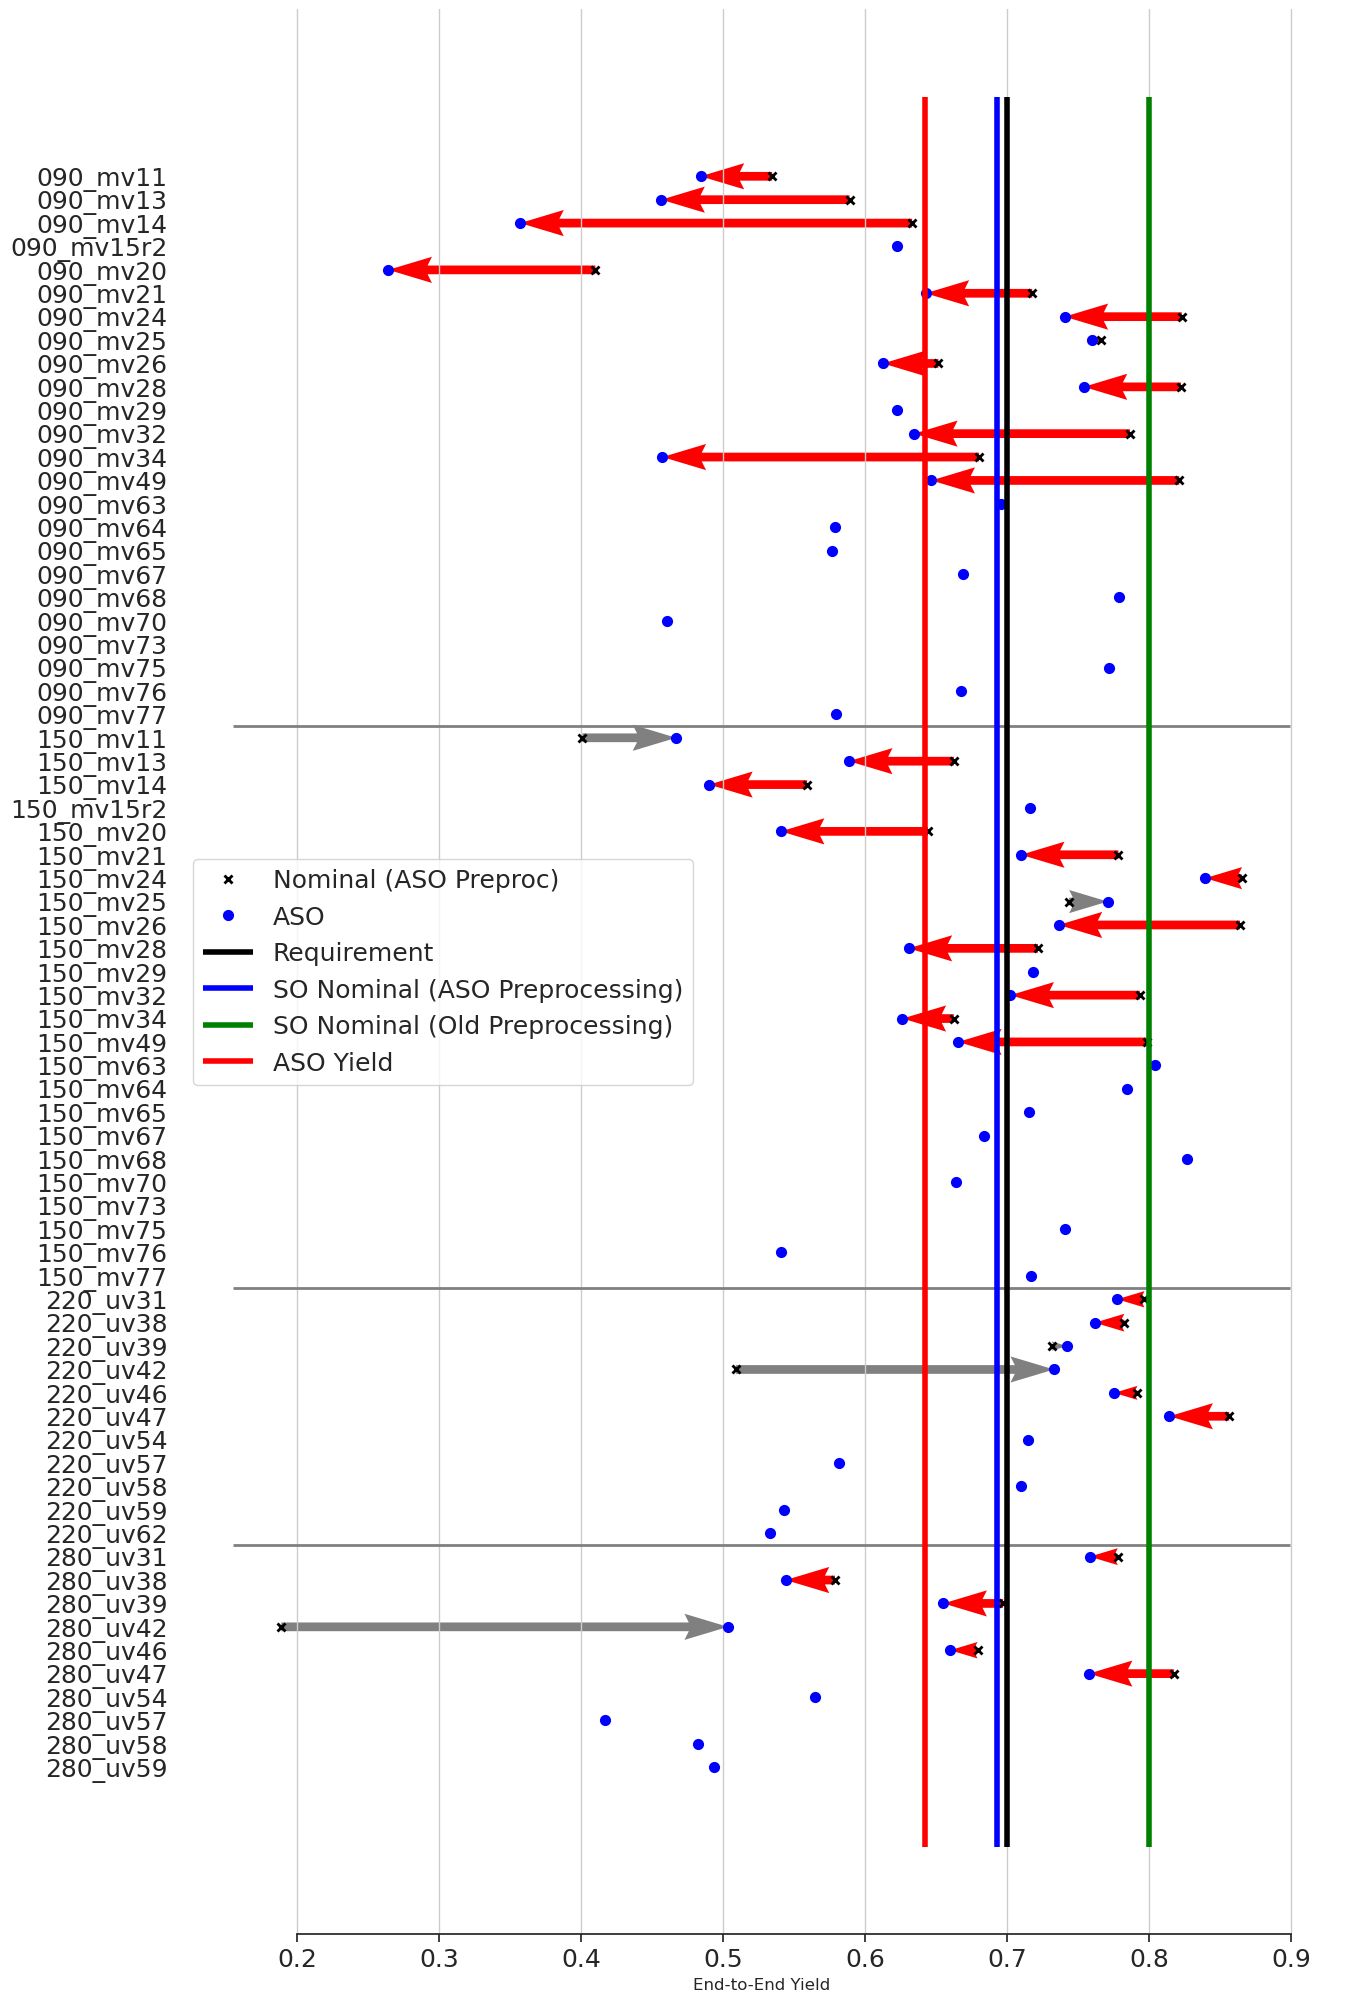

In [31]:
sns.set_theme(style="ticks")
fontsize = 18

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(15, 25))

# Add in points to show each observation
sns.pointplot(data=means_df, x="nominal_yields", y="labels", linestyle="none", marker="x", color="black", zorder=2, label="Nominal (ASO Preproc)", markersize=6)
plot = sns.pointplot(data=means_df, x="aso_yields", y="labels", linestyle="none", marker="o", color="blue", zorder=2, label="ASO", markersize=6)

plot.quiver(
    nominal,  # X arrow start
    means_df[means_df["labels"].isin(nominal_ufms)].index,                   # Y arrow start
    aso-nominal,    # delta X (0 here since we want vertical lines)
    np.zeros_like(aso),                 # delta Y
    scale_units='xy',
    scale=1,
    color=np.where(aso<nominal, 'red', 'grey'),
    zorder=-1,
)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

pos_090 = len([label for label in set(df.labels.to_numpy()) if "090" in label]) - 0.5
pos_150 = pos_090 + len([label for label in set(df.labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df.labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df.labels.to_numpy()) if "280" in label])

plt.hlines([pos_090, pos_150, pos_220], xmin=xmin, xmax=xmax, color="0.5", linewidths=2)

plt.vlines(0.7, ymin=ymin, ymax=ymax, label="Requirement", color="black", linewidths=4)
plt.vlines(np.nanmean(means_df.nominal_yields.to_numpy()), ymin=ymin, ymax=ymax, label="SO Nominal (ASO Preprocessing)", color="blue", linewidths=4)
plt.vlines(0.80, ymin=ymin, ymax=ymax, label="SO Nominal (Old Preprocessing)", color="green", linewidths=4)

# plt.vlines(np.nanmean(df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 1 / np.sin(np.deg2rad(50))).yields),
#    ymin=ymin, ymax=ymax, label="On-Sky Average", color="black",
# )
plt.vlines(np.nanmean(means_df.aso_yields), ymin=ymin, ymax=ymax, label="ASO Yield", color="red", linewidths=4)

ax.xaxis.grid(True)
ax.set(xlabel="End-to-End Yield", ylabel="")
ax.tick_params(left=False, labelsize=fontsize)
sns.despine(trim=True, left=True)

plt.legend(fontsize=fontsize)
output_dir = Path(f"../../plts/")
output_dir.mkdir(parents=True, exist_ok=True)
f.savefig(output_dir / "nominal_yields_asopreproc.pdf", dpi=600, bbox_inches="tight")
f.savefig(output_dir / "nominal_yields_asopreproc.png", dpi=600, bbox_inches="tight")